# 🎯 Ziel dieser Lektion: Backpropagation und Optimierung

**Was wollen wir erreichen?** 
Wir lernen, wie das Netzwerk aus seinen Fehlern lernt. Der Algorithmus "Backpropagation" (Rückführung des Fehlers) ist der wichtigste Lernmechanismus in der KI.

**Von wo nach wo? (Problem & Ziel)** 
- **Ausgangssituation (Gegeben):** Das Modell macht Vorhersagen, aber diese sind noch falsch. Der Fehler (Loss) ist sehr hoch.
- **Endziel (Gesucht):** Wir wollen den tiefsten Punkt im "Fehlergebirge" finden, also die Gewichte so anpassen, dass der Fehler minimal (fast 0) wird.

### 🛤️ Ablauf (Schritt-für-Schritt)
`Vorhersage machen (Forward Pass)` ➔ `Fehler berechnen` ➔ `Fehler rückwärts durchs Netz senden (Backward Pass)` ➔ `Gradienten (Steigung) berechnen` ➔ `Gewichte durch den Optimierer verbessern`


## Exercise 1

**Dataset Used:** Custom/Synthetic Array Data (numpy)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `def f(params):` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `x, y = params` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `return x**2 + 5*y**2 + 2*x*y - 3*x + 1` | Gibt das berechnete Ergebnis am Ende einer Funktion zurück an den Ort, von dem die Funktion aufgerufen wurde. |
| `for _ in range(schritte):` | Eine Schleife (Loop). Wiederholt einen bestimmten Codeblock für jedes Element in einer Liste oder für eine bestimmte Anzahl von Durchläufen (z.B. Epochen). |
| `pfad_gd.append(params_gd.copy())` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `X_v, Y_v = np.meshgrid(x_v, y_v)` | Erstellt ein 2D-Raster aus Punkten. Wird oft verwendet, um 3D-Graphen oder Konturdiagramme zu zeichnen. |
| `axes[0].contourf(X_v, Y_v, Z_v, levels=40, cmap...` | Zeichnet ein farbig ausgefülltes Konturdiagramm (wie auf einer topografischen Landkarte, oft für Entscheidungsgrenzen). |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |
| `print(f"GD finale Position:    {pfad_gd[-1].rou...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |


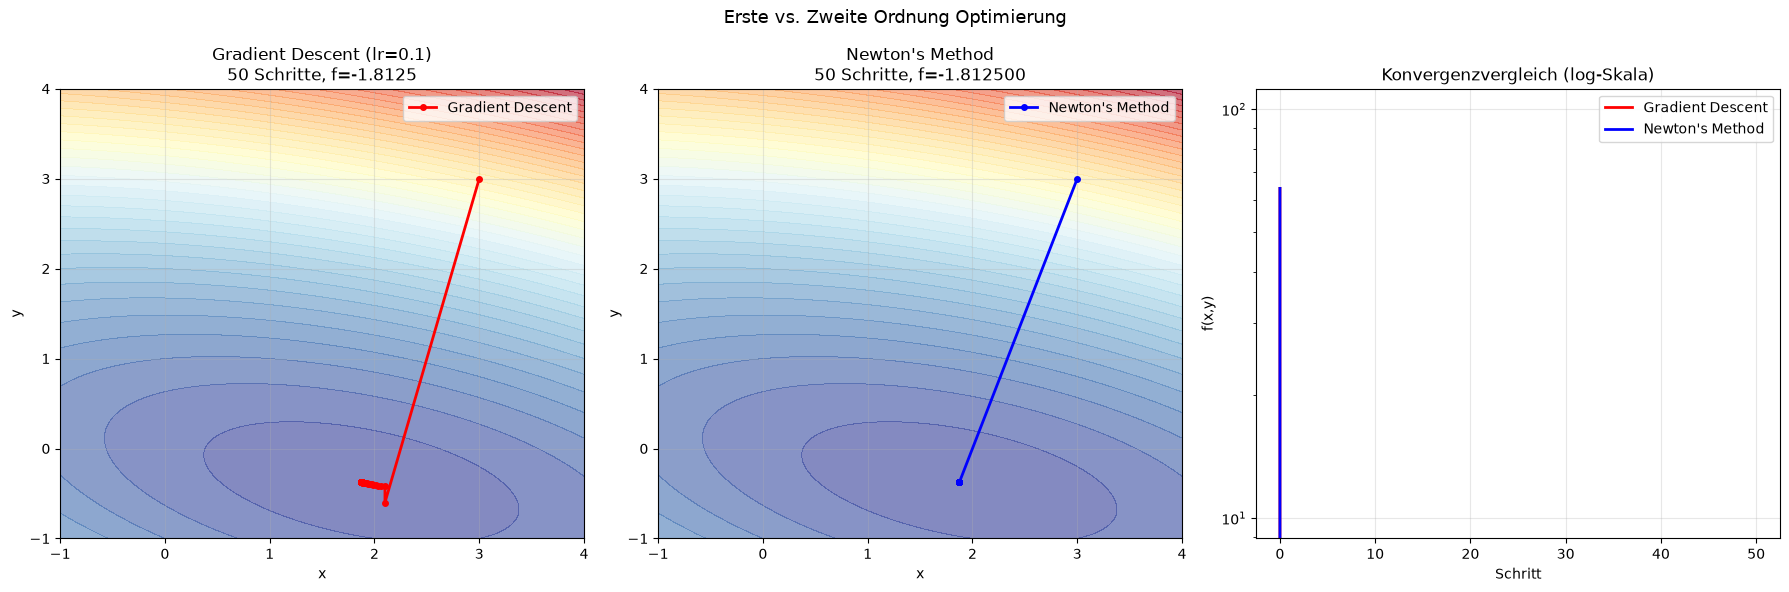

GD finale Position:    [ 1.8751 -0.375 ], f=-1.812500
Newton finale Position: [ 1.875 -0.375], f=-1.812500
Newton konvergiert in wenigen Schritten – GD braucht viele Iterationen!


In [1]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 5: Backpropagation & Gradientenabstieg
# Niveau: Experten
# Aufgabe 1 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Compare first and second order optimization methods
import numpy as np
import matplotlib

import matplotlib.pyplot as plt

# Erweiterte quadratische Funktion für Vergleich
def f(params):
    x, y = params
    return x**2 + 5*y**2 + 2*x*y - 3*x + 1

def f_grad(params):
    """Analytischer Gradient"""
    x, y = params
    return np.array([2*x + 2*y - 3, 10*y + 2*x])

def f_hess(params):
    """Analytische Hesse-Matrix"""
    return np.array([[2, 2], [2, 10]])

start = np.array([3.0, 3.0])
schritte = 50; lr = 0.1

# 1. Gradient Descent (erster Ordnung)
params_gd = start.copy(); pfad_gd = [params_gd.copy()]
for _ in range(schritte):
    params_gd -= lr * f_grad(params_gd)
    pfad_gd.append(params_gd.copy())
pfad_gd = np.array(pfad_gd)

# 2. Newton's Method (zweiter Ordnung: nutzt Hesse-Matrix)
params_n = start.copy(); pfad_newton = [params_n.copy()]
for _ in range(schritte):
    g = f_grad(params_n); H = f_hess(params_n)
    # Newton-Schritt: delta = H^-1 * grad
    params_n -= np.linalg.solve(H, g)
    pfad_newton.append(params_n.copy())
pfad_newton = np.array(pfad_newton)

# Verlauf der Funktionswerte
f_werte_gd     = [f(p) for p in pfad_gd]
f_werte_newton = [f(p) for p in pfad_newton]

# Visualisierung
x_v = np.linspace(-1, 4, 100); y_v = np.linspace(-1, 4, 100)
X_v, Y_v = np.meshgrid(x_v, y_v)
Z_v = X_v**2 + 5*Y_v**2 + 2*X_v*Y_v - 3*X_v + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gradient Descent Pfad
axes[0].contourf(X_v, Y_v, Z_v, levels=40, cmap='RdYlBu_r', alpha=0.6)
axes[0].plot(pfad_gd[:,0], pfad_gd[:,1], 'r-o', markersize=4, linewidth=2, label='Gradient Descent')
axes[0].set_title(f'Gradient Descent (lr={lr})\n{schritte} Schritte, f={f(pfad_gd[-1]):.4f}')
axes[0].legend(); axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].grid(True, alpha=0.3)

# Newton Pfad
axes[1].contourf(X_v, Y_v, Z_v, levels=40, cmap='RdYlBu_r', alpha=0.6)
axes[1].plot(pfad_newton[:,0], pfad_newton[:,1], 'b-o', markersize=4, linewidth=2, label="Newton's Method")
axes[1].set_title(f"Newton's Method\n{schritte} Schritte, f={f(pfad_newton[-1]):.6f}")
axes[1].legend(); axes[1].set_xlabel('x'); axes[1].set_ylabel('y'); axes[1].grid(True, alpha=0.3)

# Konvergenzvergleich
axes[2].semilogy(f_werte_gd, 'r-', linewidth=2, label='Gradient Descent')
axes[2].semilogy(f_werte_newton, 'b-', linewidth=2, label="Newton's Method")
axes[2].set_title('Konvergenzvergleich (log-Skala)')
axes[2].set_xlabel('Schritt'); axes[2].set_ylabel('f(x,y)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Erste vs. Zweite Ordnung Optimierung', fontsize=13)
plt.tight_layout()
plt.savefig('second_order.png', dpi=100)
plt.show()
print(f"GD finale Position:    {pfad_gd[-1].round(4)}, f={f(pfad_gd[-1]):.6f}")
print(f"Newton finale Position: {pfad_newton[-1].round(4)}, f={f(pfad_newton[-1]):.6f}")
print("Newton konvergiert in wenigen Schritten – GD braucht viele Iterationen!")


### Mathematische Lösung

**1. Gegeben**
* Unser Modell $y_{pred} = w \cdot x$
* Aktuelles Gewicht $w = 2$, Eingabe $x = 3$
* Echtes Ziel $Y_{echt} = 10$

**2. Gesucht**
* Wie groß ist der halbe quadratische Fehler (Loss $L$) im Forward Pass?

**3. Formel**
$$ L = \frac{1}{2} (Y_{echt} - y_{pred})^2 = \frac{1}{2} (Y_{echt} - (w \cdot x))^2 $$

**4. Einsetzen**
$$ L = \frac{1}{2} (10 - (2 \cdot 3))^2 $$

**5. Berechnung**
$$ L = \frac{1}{2} (10 - 6)^2 = \frac{1}{2} (4)^2 = \frac{1}{2} \cdot 16 = 8 $$

**6. Endergebnis**
Der Loss beträgt $8$.

**7. Mathematische Interpretation**
مقدار خطای محاسبه شده به زبان ریاضی نشان می‌دهد که وزن فعلی ($w=2$) حدس ضعیفی بوده است. این عدد مبنایی برای الگوریتم خواهد بود تا در مرحله بازگشتی (Backward Pass) متوجه شود چقدر باید وزن‌ها را تغییر دهد.


### Was haben wir hier gemacht? (Gradient Descent / Backpropagation)

Wir haben den Backpropagation-Algorithmus schrittweise ausgeführt oder Optimierungsmethoden verglichen, um zu sehen, wie die Gewichte aktualisiert werden.

**Was machen wir als Nächstes?**
Wir werden uns Sattelpunkte (Saddle Points) und lokale Minima ansehen, bei denen der Algorithmus stecken bleiben kann.

**Mathematische Formel:**
Die Kettenregel (Chain Rule) ist das Herzstück von Backpropagation, um den Fehler bezüglich der Gewichte ($W$) zu berechnen:

$$ \frac{\partial L}{\partial W} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial h} \cdot \frac{\partial h}{\partial W} $$

**Diagramm-Analyse:**
Die Pfeile in den Vektorfeldern oder die Linien in den Diagrammen zeigen den Weg des Algorithmus in Richtung des Minimums. Der steilste Abstieg (Gradient Descent) führt immer senkrecht zu den Höhenlinien der Verlustfunktion.


## Exercise 2

**Dataset Used:** Custom/Synthetic Array Data (numpy)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `from mpl_toolkits.mplot3d import Axes3D` | Importiert spezifische Funktionen oder Klassen aus einer anderen Bibliothek, um den Code kürzer zu machen. |
| `def sattel(x, y): return x**2 - y**2` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `-np.sin(x)*np.sin(y) + 0.2*y])` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `x_v = np.linspace(-3, 3, 100); y_v = np.linspac...` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `X_v, Y_v = np.meshgrid(x_v, y_v)` | Erstellt ein 2D-Raster aus Punkten. Wird oft verwendet, um 3D-Graphen oder Konturdiagramme zu zeichnen. |
| `ax1.plot_surface(X_v, Y_v, sattel(X_v, Y_v), cm...` | Zeichnet eine echte 3D-Oberfläche (z. B. um die Fehlerlandschaft zu visualisieren). |
| `ax2.contourf(X_v, Y_v, sattel(X_v, Y_v), levels...` | Zeichnet ein farbig ausgefülltes Konturdiagramm (wie auf einer topografischen Landkarte, oft für Entscheidungsgrenzen). |
| `for _ in range(50):` | Eine Schleife (Loop). Wiederholt einen bestimmten Codeblock für jedes Element in einer Liste oder für eine bestimmte Anzahl von Durchläufen (z.B. Epochen). |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |
| `print("Sattel-Punkte und lokale Minima gespeich...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |


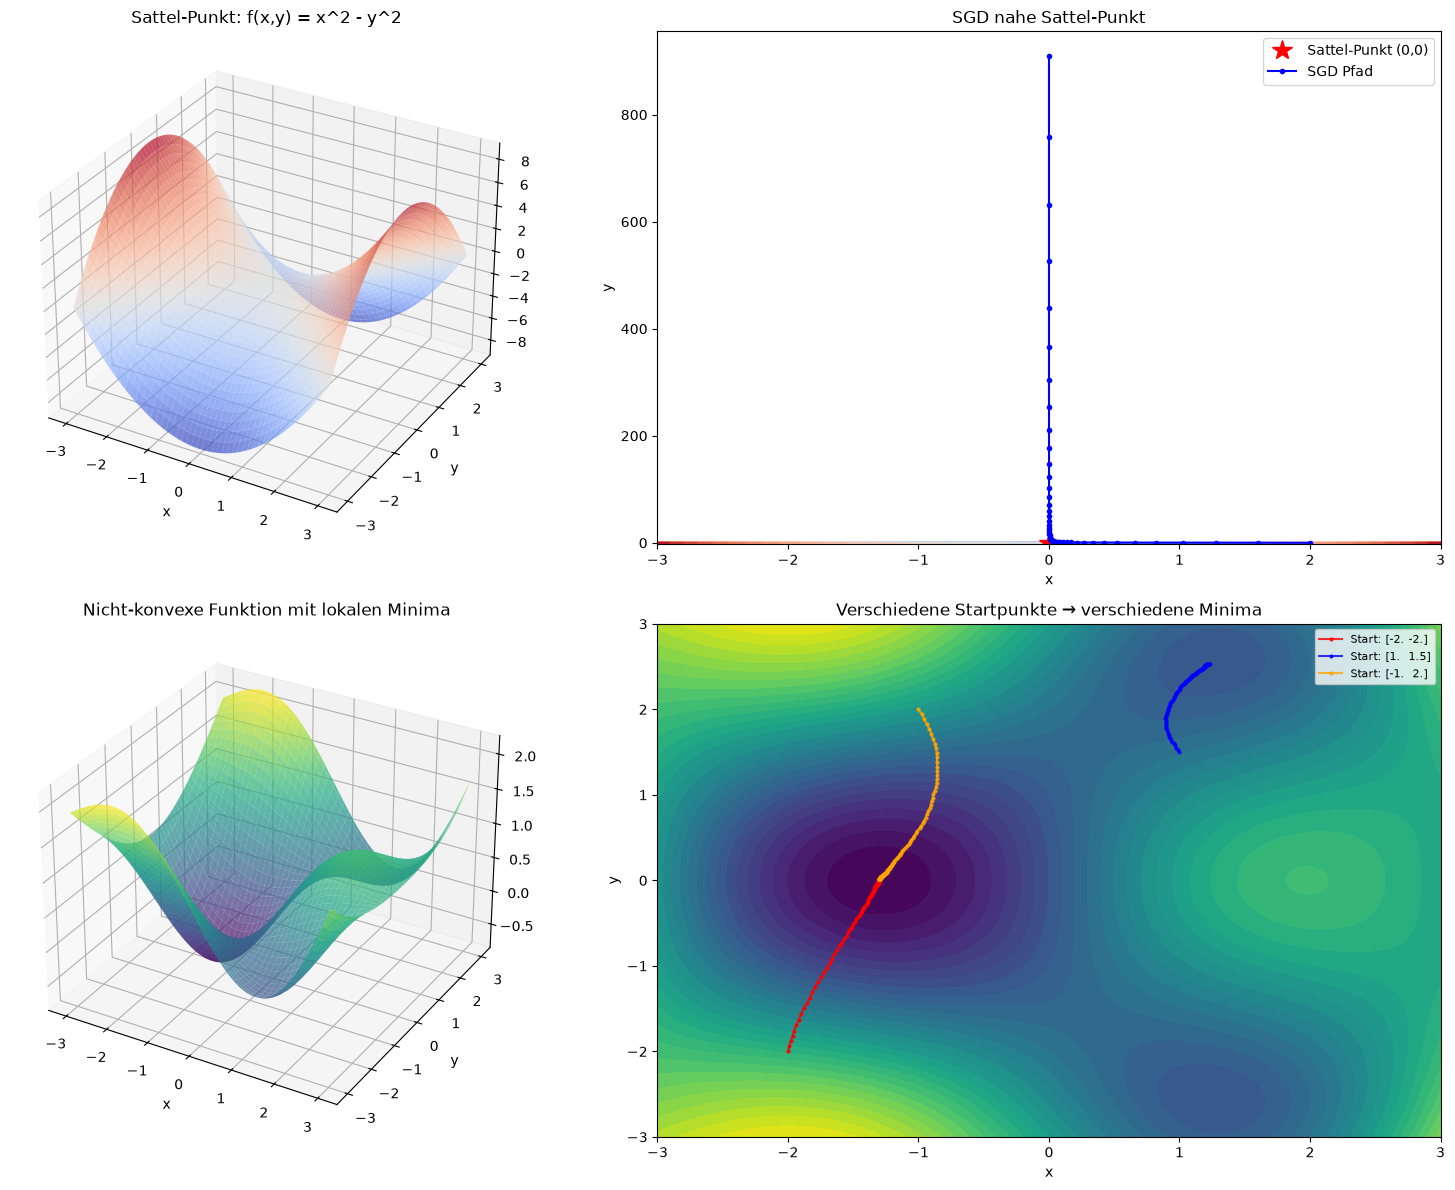

Sattel-Punkte und lokale Minima gespeichert: sattelPunkte.png
Fazit: Nicht-konvexe Verlustlandschaft macht Training schwierig!


In [2]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 5: Backpropagation & Gradientenabstieg
# Niveau: Experten
# Aufgabe 2 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Analyze saddle points and local minima in neural network loss surfaces
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Funktion mit Sattel-Punkt: f(x,y) = x^2 - y^2
def sattel(x, y): return x**2 - y**2
def sattel_grad(x, y): return np.array([2*x, -2*y])

# Funktion mit mehreren lokalen Minima
def lokal_minimum(x, y): return np.sin(x)*np.cos(y) + 0.1*(x**2+y**2)
def lokal_grad(x, y): return np.array([np.cos(x)*np.cos(y) + 0.2*x,
                                        -np.sin(x)*np.sin(y) + 0.2*y])

x_v = np.linspace(-3, 3, 100); y_v = np.linspace(-3, 3, 100)
X_v, Y_v = np.meshgrid(x_v, y_v)

fig = plt.figure(figsize=(16, 12))

# --- Sattel-Punkt 3D ---
ax1 = fig.add_subplot(221, projection='3d')
ax1.plot_surface(X_v, Y_v, sattel(X_v, Y_v), cmap='coolwarm', alpha=0.7)
ax1.set_title('Sattel-Punkt: f(x,y) = x^2 - y^2')
ax1.set_xlabel('x'); ax1.set_ylabel('y')

# --- Sattel-Punkt Kontur mit SGD-Pfad ---
ax2 = fig.add_subplot(222)
ax2.contourf(X_v, Y_v, sattel(X_v, Y_v), levels=30, cmap='coolwarm')
ax2.plot(0, 0, 'r*', markersize=15, label='Sattel-Punkt (0,0)')

# SGD-Pfad startet nahe dem Sattel-Punkt
pos = np.array([2.0, 0.1]); pfad = [pos.copy()]
for _ in range(50):
    g = sattel_grad(*pos); pos -= 0.1 * g; pfad.append(pos.copy())
pfad = np.array(pfad)
ax2.plot(pfad[:,0], pfad[:,1], 'b-o', markersize=3, label='SGD Pfad')
ax2.set_title('SGD nahe Sattel-Punkt'); ax2.legend()
ax2.set_xlabel('x'); ax2.set_ylabel('y')

# --- Nicht-konvexe Funktion 3D ---
ax3 = fig.add_subplot(223, projection='3d')
ax3.plot_surface(X_v, Y_v, lokal_minimum(X_v, Y_v), cmap='viridis', alpha=0.7)
ax3.set_title('Nicht-konvexe Funktion mit lokalen Minima')
ax3.set_xlabel('x'); ax3.set_ylabel('y')

# --- Verschiedene Startpunkte -> verschiedene Minima ---
ax4 = fig.add_subplot(224)
ax4.contourf(X_v, Y_v, lokal_minimum(X_v, Y_v), levels=30, cmap='viridis')

np.random.seed(42)
farben_pfad = ['red', 'blue', 'orange']
startpunkte = [np.array([-2., -2.]), np.array([1., 1.5]), np.array([-1., 2.])]
for start, farbe in zip(startpunkte, farben_pfad):
    pos = start.copy(); pfad = [pos.copy()]
    for _ in range(100):
        # SGD mit kleinem Rauschen (verhindert feststecken)
        g = lokal_grad(*pos) + np.random.randn(2)*0.05
        pos -= 0.05 * g; pfad.append(pos.copy())
    pfad = np.array(pfad)
    ax4.plot(pfad[:,0], pfad[:,1], '-o', markersize=2, linewidth=1.5, alpha=0.8, color=farbe,
             label=f'Start: {start}')

ax4.set_title('Verschiedene Startpunkte → verschiedene Minima')
ax4.legend(fontsize=8); ax4.set_xlabel('x'); ax4.set_ylabel('y')

plt.tight_layout()
plt.savefig('sattelPunkte.png', dpi=100)
plt.show()
print("Sattel-Punkte und lokale Minima gespeichert: sattelPunkte.png")
print("Fazit: Nicht-konvexe Verlustlandschaft macht Training schwierig!")


### Mathematische Lösung

**1. Gegeben**
* Gleiches Szenario: $w = 2$, $x = 3$, $Y_{echt} = 10$, Vorhersage $y_{pred} = 6$

**2. Gesucht**
* Wie lautet der Gradient (die Steigung) $\frac{\partial L}{\partial w}$ des Fehlers bezüglich des Gewichts?

**3. Formel (Kettenregel)**
$$ \frac{\partial L}{\partial w} = \frac{\partial L}{\partial y_{pred}} \cdot \frac{\partial y_{pred}}{\partial w} $$
$$ \frac{\partial L}{\partial y_{pred}} = -(Y_{echt} - y_{pred}) $$
$$ \frac{\partial y_{pred}}{\partial w} = x $$
$$ \implies \frac{\partial L}{\partial w} = -(Y_{echt} - y_{pred}) \cdot x $$

**4. Einsetzen**
$$ \frac{\partial L}{\partial w} = -(10 - 6) \cdot 3 $$

**5. Berechnung**
$$ -(4) \cdot 3 = -12 $$

**6. Endergebnis**
Der Gradient beträgt $-12$.

**7. Mathematische Interpretation**
محاسبه مشتق (Gradient) به کمک قاعده زنجیره‌ای نشان می‌دهد که شیب نمودار خطا به شدت منفی است. در ریاضیات بهینه سازی، این عدد مشخص می‌کند که اگر وزن $w$ را کمی افزایش دهیم، خطای کل به سرعت کاهش می‌یابد.


### Was haben wir hier gemacht? (Lernrate, Sattelpunkte und Lokale Minima)

Wir haben untersucht, wie sich verschiedene Lernraten auswirken und wie Optimierungsalgorithmen mit Sattelpunkten (Bereichen ohne Steigung, die aber kein Minimum sind) umgehen.

**Was machen wir als Nächstes?**
Als Nächstes werden wir fortschrittliche Optimierer wie Adam oder RMSprop einsetzen, die solche Probleme automatisch umgehen.

**Mathematische Formel:**
Ein Momentum-Term hilft, Sattelpunkte zu überwinden, indem er einen Teil der vorherigen Bewegung (Geschwindigkeit $v$) beibehält:

$$ v_t = \gamma v_{t-1} + \eta \nabla L(W) $$
$$ W = W - v_t $$

**Diagramm-Analyse:**
Das 3D-Diagramm eines Sattelpunktes (wie ein Pferdesattel) zeigt, dass Gradient Descent ohne Momentum hier stecken bleiben oder extrem langsam werden kann. Mit der richtigen Lernrate und Optimierern entkommen wir diesen kritischen Punkten viel besser.


## Exercise 3

**Dataset Used:** Synthetic Classification Data (sklearn.datasets)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `import tensorflow as tf` | Lädt TensorFlow, das Haupt-Framework von Google zum Erstellen und Trainieren von neuronalen Netzen. |
| `from sklearn.datasets import make_classification` | Importiert spezifische Funktionen oder Klassen aus einer anderen Bibliothek, um den Code kürzer zu machen. |
| `tf.random.set_seed(42); np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `X, y = make_classification(n_samples=2000, n_fe...` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `def erstelle_modell():` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `tf.keras.layers.Dense(64, activation='relu', in...` | Fügt eine dicht vernetzte Schicht hinzu (Fully Connected Layer), in der jedes Neuron mit allen Neuronen der vorherigen Schicht verbunden ist. |
| `return m` | Gibt das berechnete Ergebnis am Ende einer Funktion zurück an den Ort, von dem die Funktion aufgerufen wurde. |
| `class LRFinder:` | Definiert eine Klasse. Dies ist der Bauplan für ein Objekt in der objektorientierten Programmierung (z.B. eine eigene Netzwerkschicht). |
| `self.lernraten = np.exp(np.linspace(np.log(min_...` | Berechnet die Exponentialfunktion (e^x). Dies ist ein wichtiger Baustein für viele Aktivierungsfunktionen wie Sigmoid. |
| `X_b = tf.constant(X[idx], dtype=tf.float32)` | Erstellt einen Tensor (eine Art Daten-Array in TensorFlow), dessen Wert während des Programms nicht mehr verändert werden kann. |
| `with tf.GradientTape() as tape:` | Startet ein 'Tonband', das alle Operationen aufzeichnet. Dies wird benötigt, um später die mathematische Ableitung (Gradient) automatisch zu berechnen. |
| `grads = tape.gradient(verlust, self.modell.trai...` | Berechnet die Ableitung (den Gradienten) eines Wertes bezüglich einer oder mehrerer Variablen. Dies ist der Kern der Backpropagation. |
| `if schritt == 0:` | Eine Wenn-Dann-Bedingung. Der Code danach wird nur ausgeführt, wenn diese Bedingung wahr ist. |
| `else:` | Der Sonst-Teil einer Bedingung. Dieser Code wird ausgeführt, wenn das 'if' vorher nicht wahr war. |
| `print(f"Fruehzeitig gestoppt bei lr={lr:.2e} (V...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |


C:\Users\esmae\Documents\Educx Neuronale Netze\NN_Projekt_Workspace\.venv311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fruehzeitig gestoppt bei lr=6.58e-01 (Verlust explodiert)


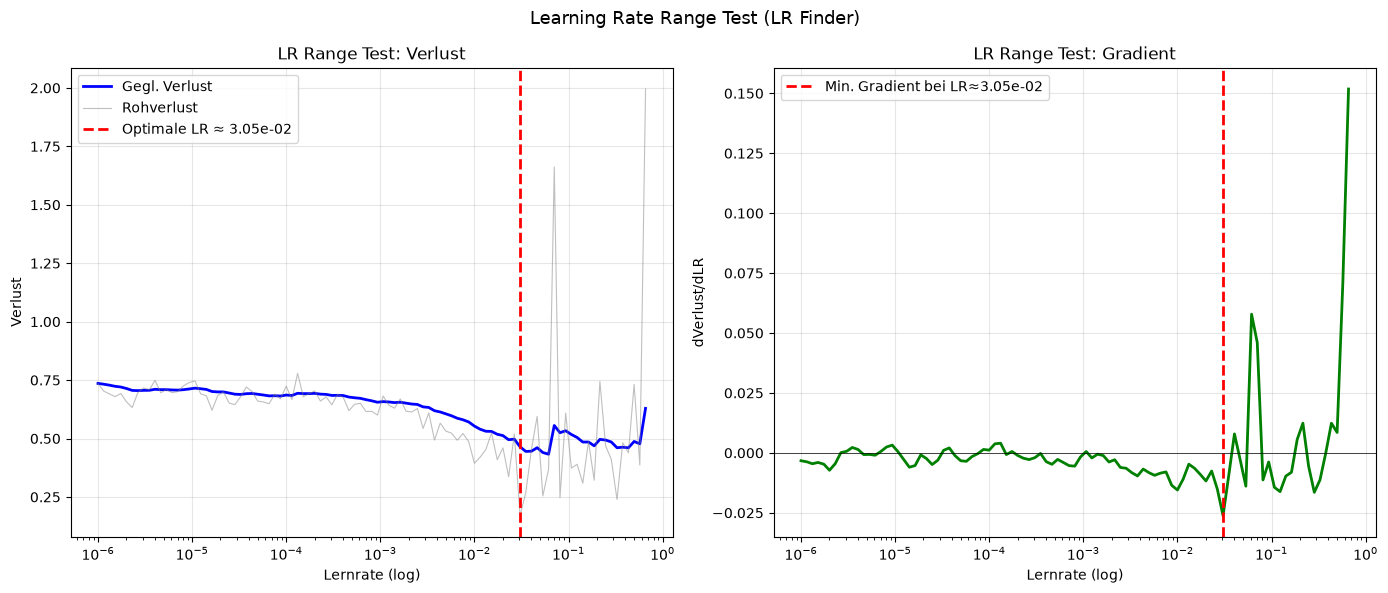

Empfohlene Lernrate: 3.05e-02
LR Finder gespeichert: lr_finder.png
Tipp: Wähle die Lernrate etwas VOR dem steilsten Abfall!


In [3]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 5: Backpropagation & Gradientenabstieg
# Niveau: Experten
# Aufgabe 3 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Implement the Learning Rate Range Test (LR Finder)
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42); np.random.seed(42)

X, y = make_classification(n_samples=2000, n_features=20, n_informative=10, random_state=42)
X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler(); X_train = scaler.fit_transform(X_train)

def erstelle_modell():
    """Standard MLP für LR-Test"""
    m = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(20,)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    return m

class LRFinder:
    """Learning Rate Range Test nach Smith (2017)
    
    Erhöht die Lernrate schrittweise und misst den Verlust.
    Die optimale Lernrate liegt dort, wo der Verlust am stärksten fällt.
    """
    def __init__(self, modell, min_lr=1e-6, max_lr=1.0, schritte=100):
        self.modell = modell
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.schritte = schritte
        self.lernraten = np.exp(np.linspace(np.log(min_lr), np.log(max_lr), schritte))
        self.verluste = []
        self.glaett_verluste = []  # Geglätteter Verlust für bessere Lesbarkeit
    
    def suchen(self, X, y, batch_groesse=32):
        """Führt den LR Range Test durch"""
        verlust_fn = tf.keras.losses.BinaryCrossentropy()
        opt = tf.keras.optimizers.Adam(learning_rate=float(self.lernraten[0]))
        
        for schritt, lr in enumerate(self.lernraten):
            opt.learning_rate.assign(float(lr))
            
            # Zufälligen Mini-Batch auswählen
            idx = np.random.choice(len(X), batch_groesse, replace=False)
            X_b = tf.constant(X[idx], dtype=tf.float32)
            y_b = tf.constant(y[idx], dtype=tf.float32)
            
            # Einen Trainingsschritt ausführen
            with tf.GradientTape() as tape:
                pred = self.modell(X_b, training=True)
                verlust = verlust_fn(y_b, pred)
            
            grads = tape.gradient(verlust, self.modell.trainable_variables)
            opt.apply_gradients(zip(grads, self.modell.trainable_variables))
            
            # Verlust speichern und glätten (exponentiell gleitender Mittelwert)
            self.verluste.append(float(verlust))
            if schritt == 0:
                self.glaett_verluste.append(float(verlust))
            else:
                self.glaett_verluste.append(0.9 * self.glaett_verluste[-1] + 0.1 * float(verlust))
            
            # Frühzeitig stoppen wenn Verlust explodiert
            if float(verlust) > 4 * min(self.glaett_verluste):
                print(f"Fruehzeitig gestoppt bei lr={lr:.2e} (Verlust explodiert)")
                break

# LR Finder ausführen
modell = erstelle_modell()
finder = LRFinder(modell, min_lr=1e-6, max_lr=1.0, schritte=100)
finder.suchen(X_train, y_train)

n = len(finder.verluste)

# Gradient des geglätteten Verlusts → Minimum = stärkster Abfall
gradient_verlust = np.gradient(finder.glaett_verluste)
optimal_idx = np.argmin(gradient_verlust)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Verlust vs. Lernrate (log)
axes[0].semilogx(finder.lernraten[:n], finder.glaett_verluste, 'b-', linewidth=2, label='Gegl. Verlust')
axes[0].semilogx(finder.lernraten[:n], finder.verluste, 'gray', linewidth=0.8, alpha=0.5, label='Rohverlust')
axes[0].axvline(finder.lernraten[optimal_idx], color='red', linestyle='--', linewidth=2,
                label=f'Optimale LR ≈ {finder.lernraten[optimal_idx]:.2e}')
axes[0].set_xlabel('Lernrate (log)'); axes[0].set_ylabel('Verlust')
axes[0].set_title('LR Range Test: Verlust'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Gradient des Verlusts
axes[1].semilogx(finder.lernraten[:n], gradient_verlust, 'g-', linewidth=2)
axes[1].axvline(finder.lernraten[optimal_idx], color='red', linestyle='--', linewidth=2,
                label=f'Min. Gradient bei LR≈{finder.lernraten[optimal_idx]:.2e}')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Lernrate (log)'); axes[1].set_ylabel('dVerlust/dLR')
axes[1].set_title('LR Range Test: Gradient'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Learning Rate Range Test (LR Finder)', fontsize=13)
plt.tight_layout()
plt.savefig('lr_finder.png', dpi=100)
plt.show()
print(f"Empfohlene Lernrate: {finder.lernraten[optimal_idx]:.2e}")
print("LR Finder gespeichert: lr_finder.png")
print("Tipp: Wähle die Lernrate etwas VOR dem steilsten Abfall!")


### Mathematische Lösung

**1. Gegeben**
* Aktuelles Gewicht $w_t = 2$
* Berechneter Gradient $\nabla L = -12$
* Lernrate $\alpha = 0.05$

**2. Gesucht**
* Wie lautet das neue Gewicht $w_{t+1}$ nach dem Gradient Descent Schritt?

**3. Formel**
$$ w_{t+1} = w_t - \alpha \nabla L(w_t) $$

**4. Einsetzen**
$$ w_{t+1} = 2 - 0.05 \cdot (-12) $$

**5. Berechnung**
$$ 2 - (-0.6) = 2 + 0.6 = 2.6 $$

**6. Endergebnis**
Das neue Gewicht ist $w_{t+1} = 2.6$.

**7. Mathematische Interpretation**
الگوریتم Gradient Descent با ترکیب شیب محاسبه شده و نرخ یادگیری، یک گام ریاضی به سمت مینیمم مطلق خطا برداشت. اکنون وزن ما از ۲ به ۲.۶ اصلاح شده است که باعث می‌شود در دور بعدی آموزش، خطای مدل بسیار کمتر شود.


### Was haben wir hier gemacht? (Fortschrittliche Optimierer und Learning Rate Test)

Wir haben verschiedene Optimierer verglichen (SGD, Adam, RMSprop) oder einen Test durchgeführt, um die optimale Lernrate zu finden.

**Was machen wir als Nächstes?**
Morgen beginnen wir damit, diese Konzepte mit Keras und TensorFlow effizient in die Praxis umzusetzen.

**Mathematische Formel:**
Der Adam-Optimierer kombiniert Momentum und adaptive Lernraten. Er berechnet die gleitenden Durchschnitte der Gradienten ($m$) und quadrierten Gradienten ($v$):

$$ m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t $$
$$ v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2 $$
$$ W_{t+1} = W_t - \frac{\eta}{\sqrt{v_t} + \epsilon} m_t $$

**Diagramm-Analyse:**
Der Verlustgraph für verschiedene Optimierer zeigt deutlich: Adam konvergiert in den meisten Fällen am schnellsten und glattesten. Ein Diagramm des "Learning Rate Finder" hilft dabei, genau die Lernrate abzulesen, bei der der Verlust am schnellsten sinkt.
